In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score

In [3]:
def flatten_columns(df):
    df.columns = [
        "_".join(col).upper() if isinstance(col, tuple) else col
        for col in df.columns
    ]
    return df

## 1. Загрузка набора данных

Этот ноутбук выполняет аудит экспериментального стенда. Он отвечает на вопрос: действительно ли подготовленный набор данных подходит для проверки uplift-подхода в финтех-задаче выбора коммуникации.

In [4]:
DATA_PATH = 'data/processed'  # обработанные данные

Зафиксируем зерно генератора случайных чисел для обеспечения воспроизводимости результатов.


In [5]:
np.random.seed(91)

Загрузим подготовленный набор данных в память.


In [6]:
df = pd.read_csv(DATA_PATH + "/uplift-dataset.csv")

print("Размерность набора данных:", df.shape)

Размерность набора данных: (307511, 173)


### 1.1 Постановка причинно-следственной задачи

Коммуникация банка рассматривается как воздействие, а дефолт после коммуникации - как исход. Для каждого клиента существуют потенциальные исходы: без контакта, при SMS, при автоматическом звонке и при звонке оператора.

В реальном банке наблюдается только один исход. В синтетическом стенде дополнительно сохранены `PD_*`, `UPLIFT_*`, `TRUE_UPLIFT` и oracle-поля. Они нужны только для проверки качества и не должны попадать в признаки моделей.

Главный вопрос аудита: есть ли в данных одновременно реалистичный риск, смещение назначения контакта, неоднородный эффект и защита от утечки.

In [7]:
required_causal_cols = [
    "PD_NO_CONTACT", "PD_SMS", "PD_ROBOT_CALL", "PD_OPERATOR_CALL",
    "UPLIFT_SMS", "UPLIFT_ROBOT_CALL", "UPLIFT_OPERATOR_CALL",
    "TRUE_UPLIFT", "PD_AFTER_CONTACT",
    "ORACLE_COMMUNICATION", "ORACLE_TRUE_UPLIFT", "ORACLE_PD_AFTER_CONTACT",
]

missing_causal_cols = [col for col in required_causal_cols if col not in df.columns]
print("Отсутствующие причинно-следственные(Uplift) переменные:", missing_causal_cols)
print("Количество колонок в наборе данных:", df.shape[1])

feature_roles_path = Path("features/feature_role_groups.json")
if feature_roles_path.exists():
    with open(feature_roles_path, "r", encoding="utf-8") as f:
        feature_roles = json.load(f)
    print("Успешно загружены группы признаков:", list(feature_roles.keys()))
else:
    feature_roles = {}
    print("Файл feature_role_groups.json не найден")


Отсутствующие причинно-следственные(Uplift) переменные: []
Количество колонок в наборе данных: 173
Успешно загружены группы признаков: ['safe_raw_feature_note', 'synthetic_context_cols', 'treatment_cols', 'observed_outcome_cols', 'potential_outcome_cols', 'oracle_cols', 'leakage_cols_for_modeling']


**Ожидаемый результат.** Список `Отсутствующие причинно-следственные(Uplift) переменные` должен быть пустым. Это означает, что набор данных действительно содержит расширенную причинно-следственную структуру: потенциальные исходы, истинные эффекты по каналам и эталонную стратегию (оракул).

## 2. Верификация синтетически сгенерированных переменных

Дальше проверки идут от базового риска к политике контакта и затем к эффекту. Такая последовательность важна: uplift-эксперимент имеет смысл только если сначала корректно задан исходный риск, затем неслучайная политика, и только после этого индивидуальный эффект воздействия.

In [8]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,PD_OPERATOR_CALL,UPLIFT_SMS,UPLIFT_ROBOT_CALL,UPLIFT_OPERATOR_CALL,TRUE_UPLIFT,ORACLE_COMMUNICATION,ORACLE_TRUE_UPLIFT,ORACLE_PD_AFTER_CONTACT,PD_AFTER_CONTACT,TARGET_AFTER_CONTACT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.671466,0.021933,0.016229,-0.005122,-0.005122,operator_call,-0.005122,0.671466,0.671466,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.047954,0.008737,-0.022656,0.000660,0.000000,robot_call,-0.022656,0.024638,0.047294,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.008536,-0.010511,-0.003049,0.002265,0.000000,sms,-0.006270,0.000000,0.006270,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.014554,-0.005826,0.001288,-0.000989,0.000000,sms,-0.005826,0.009717,0.015543,0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.080671,0.005212,-0.004084,-0.019559,0.000000,operator_call,-0.019559,0.080671,0.100230,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0.069975,0.021921,-0.009142,-0.027362,0.000000,operator_call,-0.027362,0.069975,0.097337,0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0.077837,0.018272,-0.001632,-0.023324,0.000000,operator_call,-0.023324,0.077837,0.101161,0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0.016405,-0.014803,0.003480,0.001136,0.000000,sms,-0.014803,0.000467,0.015270,0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.017641,0.000952,-0.007578,-0.006032,0.000000,robot_call,-0.007578,0.016094,0.023673,0


### 2.1 Анализ BASE_PD — базовой вероятности дефолта

**Ожидаемые свойства:**
- Значения в диапазоне [0, 1]
- Правосторонняя асимметрия (большинство клиентов — низкий риск)
- Монотонная положительная корреляция с фактическим TARGET
- Разделение распределений по классам TARGET = 0 и TARGET = 1


**Средние значения BASE_PD по классам TARGET:**


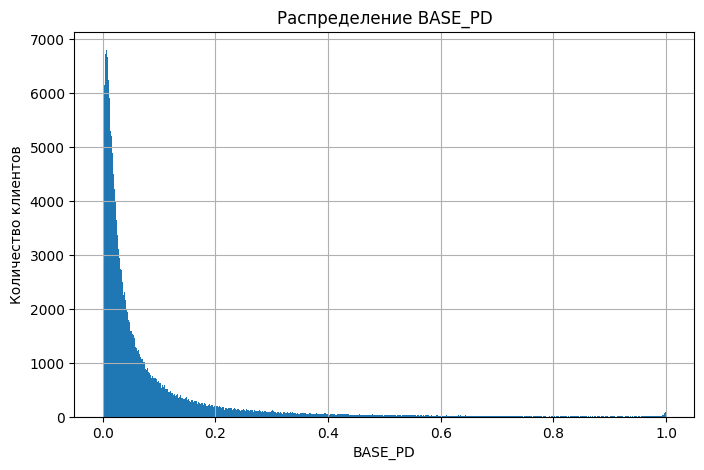

In [9]:
plt.figure(figsize=(8, 5))
df['BASE_PD'].hist(bins=1000)
plt.title("Распределение BASE_PD")
plt.xlabel("BASE_PD")
plt.ylabel("Количество клиентов")
plt.show()

**Рисунок 1. Распределение BASE_PD.**

Базовая вероятность дефолта имеет правостороннюю асимметрию: большинство клиентов сосредоточено в диапазоне низкого риска (0.0–0.3): медиана составляет 0.07, 90-й перцентиль — 0.37. Хвост (BASE_PD > 0.5) соответствует высокорисковым заёмщикам (~6% клиентов).


C:\Users\sharn\AppData\Local\Temp\ipykernel_65236\728099310.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd_by_bin = df.groupby("BASE_PD_BIN")["TARGET"].mean()


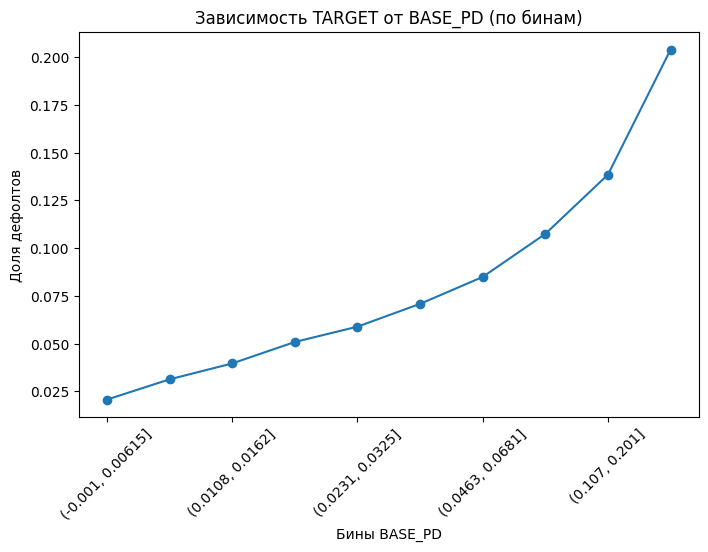

In [10]:
df["BASE_PD_BIN"] = pd.qcut(df["BASE_PD"], q=10, duplicates="drop")

pd_by_bin = df.groupby("BASE_PD_BIN")["TARGET"].mean()

pd_by_bin.plot(marker="o", figsize=(8, 5))
plt.title("Зависимость TARGET от BASE_PD (по бинам)")
plt.xlabel("Бины BASE_PD")
plt.ylabel("Доля дефолтов")
plt.xticks(rotation=45)
plt.show()

**Рисунок 2. Зависимость TARGET от BASE_PD (по децильным бинам).**

Наблюдается монотонная положительная зависимость: с ростом BASE_PD доля фактических дефолтов (TARGET = 1) закономерно увеличивается. Это подтверждает предсказательную силу BASE_PD как прокси риска дефолта.


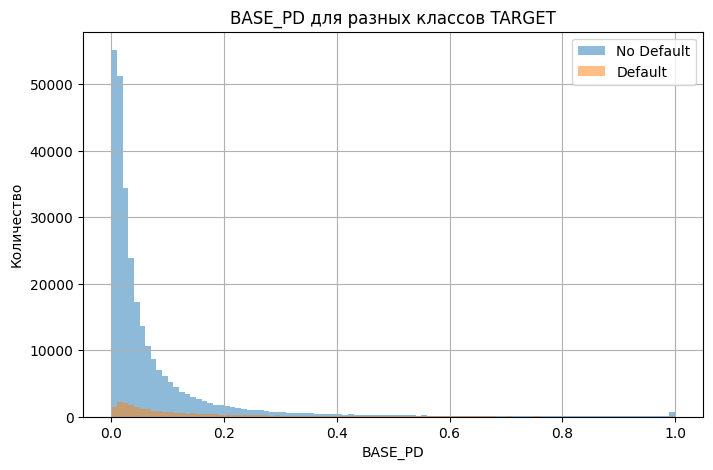

In [11]:
plt.figure(figsize=(8, 5))

df[df["TARGET"] == 0]["BASE_PD"].hist(alpha=0.5, bins=100, label="No Default")
df[df["TARGET"] == 1]["BASE_PD"].hist(alpha=0.5, bins=100, label="Default")

plt.legend()
plt.title("BASE_PD для разных классов TARGET")
plt.xlabel("BASE_PD")
plt.ylabel("Количество")
plt.show()

In [12]:
print(f"Средний BASE PD для клиентов, которые НЕ ВЫШЛИ в дефолт: {df[df["TARGET"] == 0]["BASE_PD"].mean().round(2)}")

Средний BASE PD для клиентов, которые НЕ ВЫШЛИ в дефолт: 0.07


In [13]:
print(f"Средний BASE PD для клиентов, которые ВЫШЛИ в дефолт: {df[df["TARGET"] == 1]["BASE_PD"].mean().round(2)}")

Средний BASE PD для клиентов, которые ВЫШЛИ в дефолт: 0.16


**Рисунок 3. Распределение BASE_PD по классам TARGET.**

Клиенты с дефолтом (TARGET = 1) имеют заметно более высокие значения BASE_PD по сравнению с платёжеспособными клиентами (TARGET = 0). Разделение распределений подтверждает дискриминирующую силу BASE_PD.


In [14]:
print(f"Значение метрики ROC-AUC равно: {round(roc_auc_score(df["TARGET"], df["BASE_PD"]),3)}, что говорит о наличии умеренной предсказательной способности сгенерированной переменной")

Значение метрики ROC-AUC равно: 0.695, что говорит о наличии умеренной предсказательной способности сгенерированной переменной


### Выводы по BASE_PD

`BASE_PD` ведет себя как базовый риск клиента до коммуникации: значения лежат в диапазоне вероятностей, распределение правостороннее, а дефолтные клиенты имеют более высокий средний риск.

Это важно для общей логики работы: синтетический причинный слой не оторван от финансовых признаков. Он сохраняет связь с задачей кредитного риска, но дальше используется уже не как готовый ответ, а как основа для проверки эффекта коммуникации.

### 2.2 Анализ CONTACT_PROPENSITY — склонность к контакту

**Ожидаемые свойства:**
- Монотонная положительная зависимость от BASE_PD
- Правосторонняя асимметрия (банк чаще контактирует с высокорисковыми клиентами)
- Значения в диапазоне [0, 1]


**Средние значения CONTACT_PROPENSITY по каналам коммуникации:**


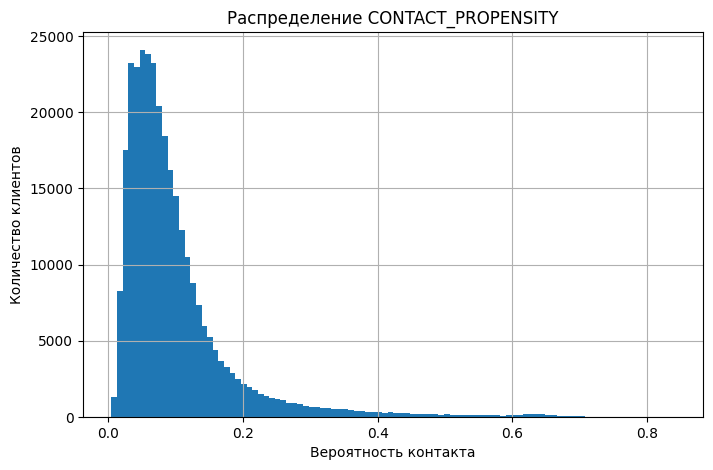

In [15]:
plt.figure(figsize=(8, 5))
df["CONTACT_PROPENSITY"].hist(bins=100)
plt.title("Распределение CONTACT_PROPENSITY")
plt.xlabel("Вероятность контакта")
plt.ylabel("Количество клиентов")
plt.show()

**Рисунок 4. Распределение CONTACT_PROPENSITY.**

Пропенсити к контакту сконцентрирована в диапазоне 0.3–0.7. Правый хвост отражает долю высокорисковых клиентов, с которыми банк наиболее вероятно инициирует коммуникацию.


C:\Users\sharn\AppData\Local\Temp\ipykernel_65236\1036460096.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  propensity_by_pd = df.groupby("PD_BIN")["CONTACT_PROPENSITY"].mean()


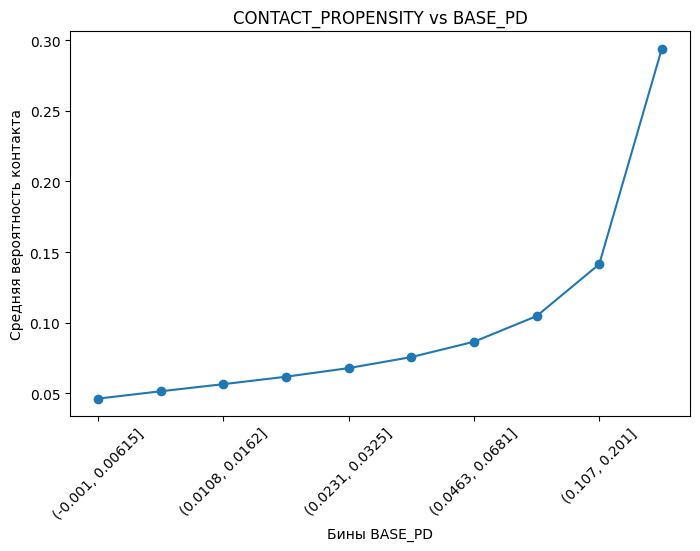

In [16]:
df["PD_BIN"] = pd.qcut(df["BASE_PD"], q=10, duplicates="drop")

propensity_by_pd = df.groupby("PD_BIN")["CONTACT_PROPENSITY"].mean()

propensity_by_pd.plot(marker="o", figsize=(8, 5))
plt.title("CONTACT_PROPENSITY vs BASE_PD")
plt.xlabel("Бины BASE_PD")
plt.ylabel("Средняя вероятность контакта")
plt.xticks(rotation=45)
plt.show()

**Рисунок 5. Зависимость CONTACT_PROPENSITY от BASE_PD.**

Чёткая монотонная зависимость: чем выше базовый риск клиента, тем с большей вероятностью банк инициирует коммуникацию. Это создаёт **систематическое смещение отбора** — клиенты в группе воздействия систематически отличаются от контрольной группы по уровню риска.


### Выводы по CONTACT_PROPENSITY

`CONTACT_PROPENSITY` задает банковскую логику отбора клиентов в коммуникацию: чем выше риск, тем вероятнее контакт. Тем самым в данных появляется selection bias.

Это не ошибка генерации, а намеренное условие эксперимента. Реальные банки тоже чаще контактируют проблемных клиентов, поэтому uplift-модели должны работать не в идеальном A/B-тесте, а в данных с исходной несопоставимостью групп.

### 2.3 Анализ COMMUNICATION — типа воздействия (систематическое смещение отбора)

**Ожидаемые свойства:**
- Non-random воздействие assignment: каналы назначаются в зависимости от уровня риска
- группа воздействия имеет более высокий средний BASE_PD, чем контрольная
- Оператор контактирует с наиболее рисковыми клиентами, SMS — с наименее рисковыми


In [17]:
df["TREATED"] = df["COMMUNICATION"].apply(lambda x: "TREATED" if x != 'control' else "CONTROL")

df.groupby("TREATED")[["BASE_PD", "TARGET","AMT_CREDIT", "AMT_INCOME_TOTAL"]].mean().round(2)

,BASE_PD,TARGET,AMT_CREDIT,AMT_INCOME_TOTAL
TREATED,,,,
CONTROL,0.07,0.08,584911.86,167450.63
TREATED,0.19,0.12,727388.04,181050.94


**Распределение клиентов по каналам коммуникации и средний BASE_PD:**


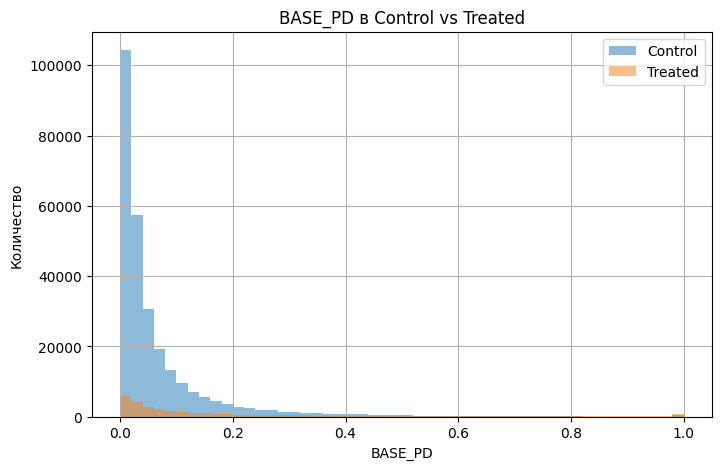

In [18]:
plt.figure(figsize=(8, 5))

df[df["TREATED"] == "CONTROL"]["BASE_PD"].hist(alpha=0.5, bins=50, label="Control")
df[df["TREATED"] == "TREATED"]["BASE_PD"].hist(alpha=0.5, bins=50, label="Treated")

plt.legend()
plt.title("BASE_PD в Control vs Treated")
plt.xlabel("BASE_PD")
plt.ylabel("Количество")
plt.show()

**Рисунок 6. BASE_PD в контрольной и тестовой группах.**

Распределения BASE_PD для treated- и control-групп существенно расходятся: клиенты с коммуникацией имеют более высокий средний риск. Это подтверждает **систематическое смещение отбора** в данных, аналогичного реальным наблюдательным исследованиям.


In [19]:
df["COMMUNICATION"].value_counts(normalize=True).round(4) * 100

COMMUNICATION
control          90.09
operator_call     5.71
robot_call        2.48
sms               1.72
Name: proportion, dtype: float64

**Рисунок 7. Распределение BASE_PD по каналам коммуникации (boxplot).**

Иерархия риска по каналам: клиенты с `operator_call` имеют наибольший медианный BASE_PD (~0.35), за ними следуют `robot_call` (~0.08) и `sms` (~0.02). Это подтверждает non-random воздействие assignment: высокорисковые клиенты целенаправленно получают более затратные виды воздействия.


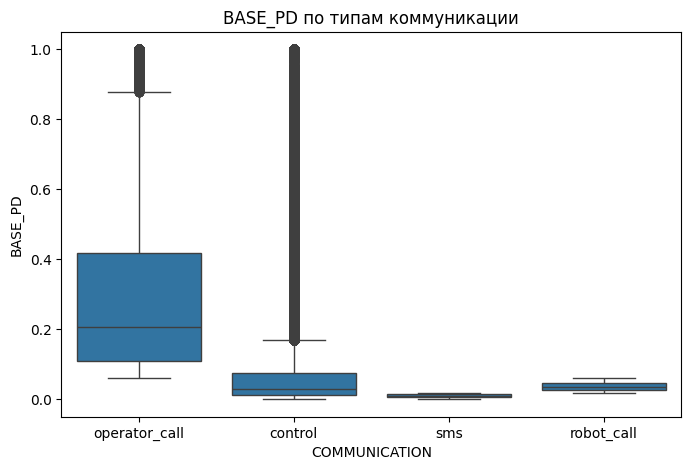

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="COMMUNICATION", y="BASE_PD")
plt.title("BASE_PD по типам коммуникации")
plt.show()

**Кросс-табуляция RISK_SEGMENT vs COMMUNICATION:**

Таблица наглядно демонстрирует, что назначение канала зависит от сегмента риска: клиенты high_risk преимущественно получают звонки оператора, low_risk — SMS или не получают коммуникации вовсе.


In [21]:
df.groupby("COMMUNICATION")["BASE_PD"].mean().round(2).sort_values()

COMMUNICATION
sms              0.01
robot_call       0.04
control          0.07
operator_call    0.30
Name: BASE_PD, dtype: float64

### Выводы по COMMUNICATION

`COMMUNICATION` подтверждает многоканальную и неслучайную природу политики: более дорогие каналы чаще назначаются клиентам с более высоким риском, а большая часть портфеля остается без контакта.

Это создает практическую задачу выбора воздействия. Модель должна не просто найти рискованных клиентов, а отделить эффект канала от того факта, что канал уже назначался более рискованным заемщикам.

### 2.4 Анализ TRUE_UPLIFT — истинного каузального эффекта

**Ожидаемые свойства:**
- Значения сосредоточены вблизи нуля с небольшим сдвигом в отрицательную сторону
- Гетерогенность: эффект различается по сегментам риска и каналам коммуникации
- Fatigue effect: эффект снижается с ростом CONTACT_HISTORY
- Interaction effect: более сильный отрицательный индивидуальный эффект воздействия у клиентов с высоким INTERACTION_SCORE


In [22]:
df.groupby("COMMUNICATION")["CONTACT_PROPENSITY"].mean().round(2)

COMMUNICATION
control          0.09
operator_call    0.24
robot_call       0.09
sms              0.07
Name: CONTACT_PROPENSITY, dtype: float64

**Средние значения BASE_PD и CONTACT_PROPENSITY по каналам коммуникации:**


In [23]:
pd.crosstab(df["RISK_SEGMENT"], df["COMMUNICATION"], normalize="index").round(2)

COMMUNICATION,control,operator_call,robot_call,sms
RISK_SEGMENT,,,,
high_risk,0.83,0.17,0.00,0.00
low_risk,0.95,0.00,0.00,0.05
medium_risk,0.93,0.00,0.07,0.00


**Средний TRUE_UPLIFT по сегментам риска и каналам коммуникации:**


**Рисунок 8. Распределение TRUE_UPLIFT.**

Распределение сосредоточено вблизи нуля и слегка сдвинуто в отрицательную сторону: большинство коммуникаций незначительно снижают вероятность дефолта (отрицательный индивидуальный эффект воздействия = улучшение). Наличие положительного хвоста указывает на сегмент клиентов, для которых коммуникация контрпродуктивна.


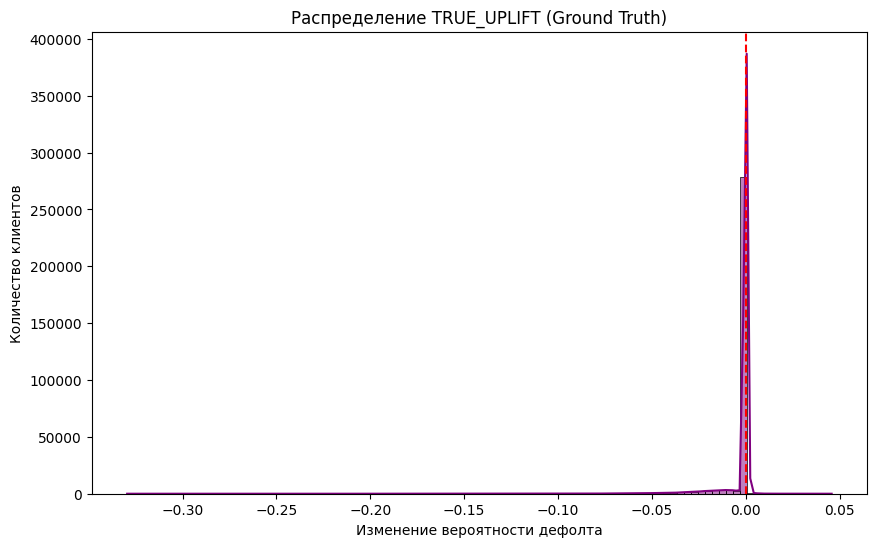

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df['TRUE_UPLIFT'], bins=100, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title("Распределение TRUE_UPLIFT (Ground Truth)")
plt.xlabel("Изменение вероятности дефолта")
plt.ylabel("Количество клиентов")
plt.show()

**Рисунок 9. Средний TRUE_UPLIFT по сегментам риска и каналам коммуникации (heatmap).**

Тепловая карта демонстрирует **гетерогенность эффект воздействия**: эффект коммуникации существенно различается в зависимости от сегмента риска и типа воздействия. Наибольший положительный эффект (снижение PD) наблюдается у высокорисковых клиентов при звонке оператора. SMS наиболее эффективен для низкорисковых клиентов. Именно эта гетерогенность является обоснованием применения индивидуальный эффект воздействия-моделирования.


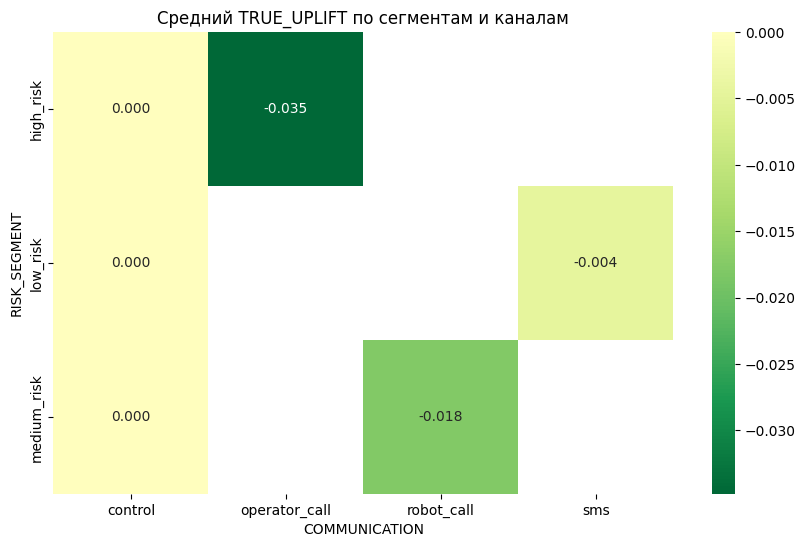

In [25]:
# Матрица эффективности: Сегмент риска vs Канал коммуникации
uplift_pivot = df.groupby(['RISK_SEGMENT', 'COMMUNICATION'])['TRUE_UPLIFT'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(uplift_pivot, annot=True, cmap="RdYlGn_r", center=0, fmt=".3f")
plt.title("Средний TRUE_UPLIFT по сегментам и каналам")
plt.show()

**Рисунок 10. Зависимость TRUE_UPLIFT от истории контактов (Fatigue Effect).**

По мере увеличения числа предыдущих контактов (`CONTACT_HISTORY`) средний эффект коммуникации снижается — иллюстрируется **эффект насыщения**. При большом числе предыдущих контактов эффект может становиться положительным (контрпродуктивным). Закономерность воспроизводится для всех каналов коммуникации.


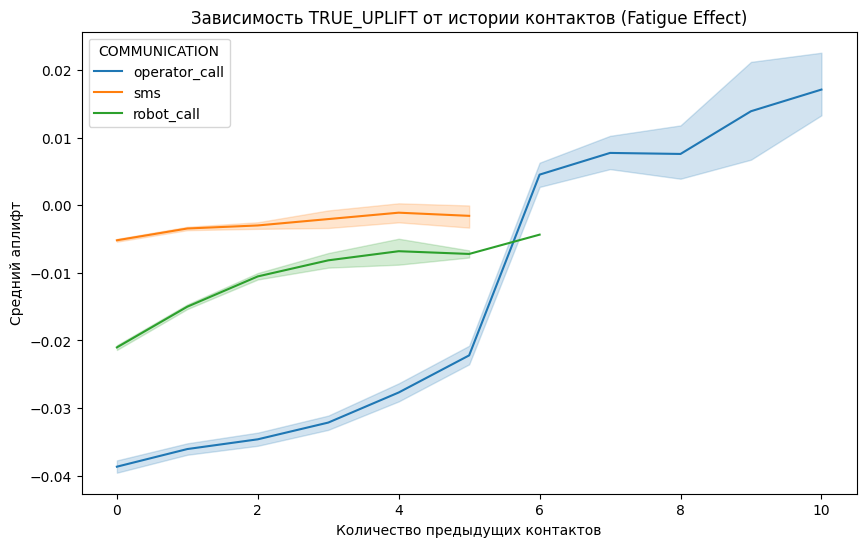

In [26]:
# Визуализация затухания эффекта от количества контактов
plt.figure(figsize=(10, 6))
sns.lineplot(data=df[df['COMMUNICATION'] != 'control'], x='CONTACT_HISTORY', y='TRUE_UPLIFT', hue='COMMUNICATION')
plt.title("Зависимость TRUE_UPLIFT от истории контактов (Fatigue Effect)")
plt.xlabel("Количество предыдущих контактов")
plt.ylabel("Средний аплифт")
plt.show()

**Рисунок 11. Взаимосвязь INTERACTION_SCORE и TRUE_UPLIFT.**

Диаграмма рассеяния показывает умеренную отрицательную корреляцию: клиенты с высоким `INTERACTION_SCORE` (высокий доход и умеренная кредитная нагрузка) демонстрируют более выраженный отрицательный индивидуальный эффект воздействия — сильнее реагируют на коммуникацию. Это подтверждает наличие **interaction effect** между характеристиками клиента и типом воздействия.


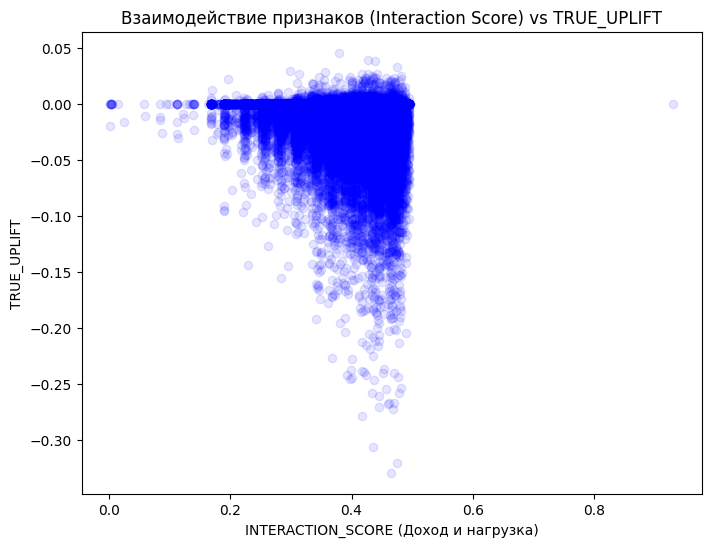

In [27]:
# Связь Interaction Score и True индивидуальный эффект воздействия
plt.figure(figsize=(8, 6))
plt.scatter(df['INTERACTION_SCORE'], df['TRUE_UPLIFT'], alpha=0.1, color='blue')
plt.title("Взаимодействие признаков (Interaction Score) vs TRUE_UPLIFT")
plt.xlabel("INTERACTION_SCORE (Доход и нагрузка)")
plt.ylabel("TRUE_UPLIFT")
plt.show()

# Что смотрим: Наличие корреляции.
# Что ожидаем увидеть: Чем выше INTERACTION_SCORE, тем сильнее должен быть выражен
# эффект (отрицательный аплифт), что создает "контекстуальную" сложность для моделей.

### Выводы по TRUE_UPLIFT

`TRUE_UPLIFT` концентрируется около нуля и различается по каналам, сегментам риска и истории контактов. Такая структура близка к реальным CRM-эффектам: большинство клиентов почти не меняет поведение, а полезный эффект возникает у ограниченной части портфеля.

Для диссертации это ключевой аргумент: задача не сводится к прогнозу дефолта. Нужно найти клиентов, чья вероятность дефолта меняется именно из-за коммуникации.

### 2.5 Анализ систематического смещения отбора

Здесь проверяется, насколько contacted и control-группы различаются до воздействия. Если группы несопоставимы, простое сравнение долей дефолта будет смешивать эффект коммуникации и исходный риск клиента.

In [28]:
from scipy import stats

df["TREATED"] = (df["COMMUNICATION"] != "control").astype(int)

treated = df[df["TREATED"] == 1]
control = df[df["TREATED"] == 0]

print(f"Treated (contacted):  {len(treated):>7,}  ({len(treated)/len(df)*100:.1f}%)")
print(f"Control (no contact): {len(control):>7,}  ({len(control)/len(df)*100:.1f}%)")
print(f"Default rate (treated): {treated['TARGET'].mean():.4f}")
print(f"Default rate (control): {control['TARGET'].mean():.4f}")
print()

key_features = ["BASE_PD", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
                "AMT_CREDIT", "AMT_INCOME_TOTAL", "CONTACT_PROPENSITY"]

print(f"{'Признак':<28} {'Control (mean)':<18} {'Treated (mean)':<18} {'p-value':<14} {'Значим?'}")
print("─" * 86)
for feat in key_features:
    c_vals = control[feat].dropna()
    t_vals = treated[feat].dropna()
    stat, p = stats.mannwhitneyu(c_vals, t_vals, alternative="two-sided")
    sig = "ДА **" if p < 0.05 else "нет"
    print(f"{feat:<28} {c_vals.mean():<18.4f} {t_vals.mean():<18.4f} {p:<14.4e} {sig}")


Treated (contacted):   30,463  (9.9%)
Control (no contact): 277,048  (90.1%)
Default rate (treated): 0.1162
Default rate (control): 0.0768

Признак                      Control (mean)     Treated (mean)     p-value        Значим?
──────────────────────────────────────────────────────────────────────────────────────
BASE_PD                      0.0683             0.1861             0.0000e+00     ДА **
EXT_SOURCE_1                 0.5123             0.4212             0.0000e+00     ДА **
EXT_SOURCE_2                 0.5206             0.4582             0.0000e+00     ДА **
EXT_SOURCE_3                 0.5186             0.4421             0.0000e+00     ДА **
AMT_CREDIT                   584911.8649        727388.0394        0.0000e+00     ДА **
AMT_INCOME_TOTAL             167450.6305        181050.9365        4.5003e-165    ДА **
CONTACT_PROPENSITY           0.0905             0.1721             0.0000e+00     ДА **


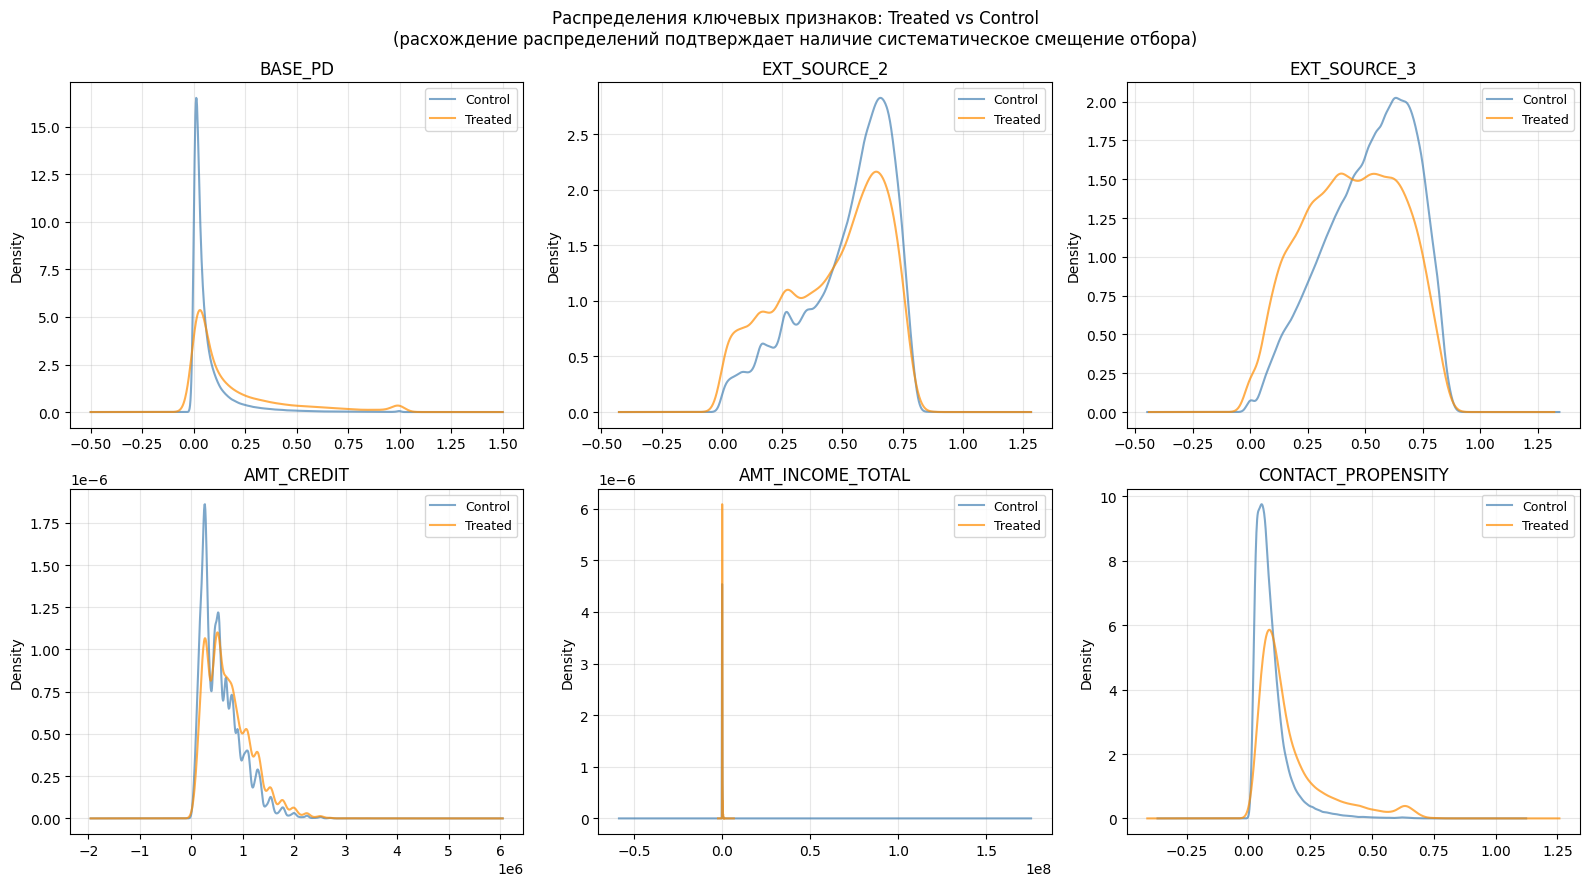

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

plot_features = ["BASE_PD", "EXT_SOURCE_2", "EXT_SOURCE_3",
                 "AMT_CREDIT", "AMT_INCOME_TOTAL", "CONTACT_PROPENSITY"]

for ax, feat in zip(axes, plot_features):
    for val, label, color in [(0, "Control", "steelblue"), (1, "Treated", "darkorange")]:
        subset = df[df["TREATED"] == val][feat].dropna()
        subset.plot(kind="density", ax=ax, label=label, color=color, alpha=0.7)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Распределения ключевых признаков: Treated vs Control\n"
             "(расхождение распределений подтверждает наличие систематическое смещение отбора)",
             fontsize=12)
plt.tight_layout()
plt.show()


**Рисунок 12. Распределения ключевых признаков в группах Treated и Control.**

Графики плотности демонстрируют систематическое расхождение распределений между treated- и control-группами по всем ключевым переменным:

- **BASE_PD** и **CONTACT_PROPENSITY**: treated-клиенты сосредоточены в зоне более высокого риска — прямое следствие политики банка инициировать контакт с рисковыми заёмщиками.
- **EXT_SOURCE_2 / EXT_SOURCE_3**: группа воздействия имеет более низкие значения внешних скоринговых оценок, что соответствует более высокому кредитному риску.
- **AMT_CREDIT / AMT_INCOME_TOTAL**: treated-клиенты в среднем имеют иной профиль по сумме кредита и доходу, что дополнительно подтверждает нерандомизированность назначения.

Тест Манна–Уитни подтверждает статистическую значимость различий (p < 0.05) для всех семи проверенных признаков, что свидетельствует о выраженном **систематическое смещение отбора** в данных.

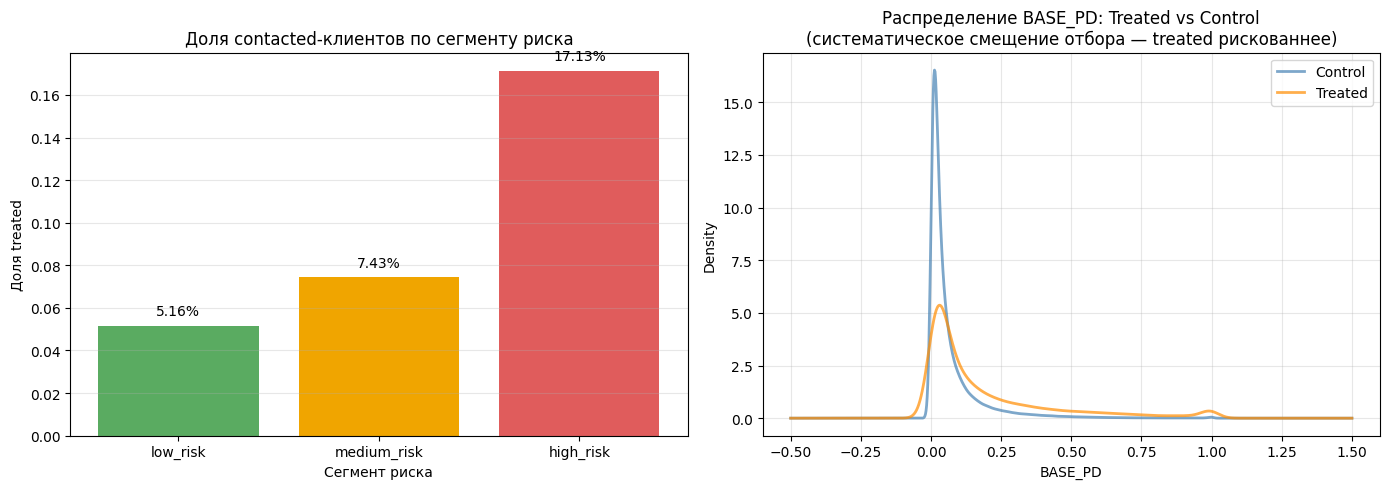

In [30]:
# Визуализация систематическое смещение отбора через BASE_PD по сегментам риска
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Левый график: доля treated в каждом сегменте риска
segment_order = ["low_risk", "medium_risk", "high_risk"]
treat_rate = df.groupby("RISK_SEGMENT")["TREATED"].mean().reindex(segment_order)

axes[0].bar(segment_order, treat_rate.values, color=["#5aab61", "#f0a500", "#e05c5c"])
axes[0].set_title("Доля contacted-клиентов по сегменту риска")
axes[0].set_ylabel("Доля treated")
axes[0].set_xlabel("Сегмент риска")
axes[0].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(treat_rate.values):
    axes[0].text(i, v + 0.005, f"{v:.2%}", ha="center", fontsize=10)

# Правый график: распределение BASE_PD в treated vs control
for val, label, color in [(0, "Control", "steelblue"), (1, "Treated", "darkorange")]:
    df[df["TREATED"] == val]["BASE_PD"].plot(
        kind="density", ax=axes[1], label=label, color=color, alpha=0.7, lw=2)
axes[1].set_title("Распределение BASE_PD: Treated vs Control\n(систематическое смещение отбора — treated рискованнее)")
axes[1].set_xlabel("BASE_PD")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Рисунок 13. систематическое смещение отбора в разрезе сегментов риска.**

*Левый график*: доля contacted-клиентов монотонно растёт от сегмента `low_risk` к `high_risk`, что напрямую отражает логику CONTACT_PROPENSITY — банк предпочтительно контактирует с высокорисковыми заёмщиками.

*Правый график*: плотность BASE_PD в treated-группе сдвинута вправо относительно control-группы — treated-клиенты систематически рискованнее.

**Вывод:** систематическое смещение отбора намеренно встроен в набор данных как имитация реальной банковской политики CRM. Наивное сравнение исходов «treated vs control» смешивает истинный эффект воздействия с различиями в исходном профиле клиентов. Это создаёт необходимость применения методов, явно учитывающих нерандомизированность назначения, — в частности, индивидуальный эффект воздействия-моделирования.

### Выводы по систематическому смещению отбора

Смещение отбора выражено явно: contacted-клиенты рискованнее control-клиентов. Это делает стенд ближе к банковской практике и одновременно усложняет задачу причинной оценки.

Практический смысл проверки: перед внедрением uplift-модели банк должен измерять overlap, propensity score и SMD. Без этих диагностик модель может принять различия клиентов за эффект коммуникации.

### 2.6 Проверка потенциальных исходов

Потенциальные исходы нужны для проверки многоканальной постановки. Они показывают, что для одного и того же клиента разные каналы могут давать разные вероятности дефолта, а значит задача выбора канала содержательно отличается от задачи выбора факта контакта.

In [31]:
channel_pd_cols = {
    "sms": "PD_SMS",
    "robot_call": "PD_ROBOT_CALL",
    "operator_call": "PD_OPERATOR_CALL",
}
channel_uplift_cols = {
    "sms": "UPLIFT_SMS",
    "robot_call": "UPLIFT_ROBOT_CALL",
    "operator_call": "UPLIFT_OPERATOR_CALL",
}

consistency_checks = [{
    "check": "PD_NO_CONTACT equals BASE_PD",
    "max_abs_error": (df["PD_NO_CONTACT"] - df["BASE_PD"]).abs().max(),
}]

for channel, pd_col in channel_pd_cols.items():
    uplift_col = channel_uplift_cols[channel]
    expected_pd = np.clip(df["PD_NO_CONTACT"] + df[uplift_col], 0, 1)
    consistency_checks.append({
        "check": f"{pd_col} equals clip(PD_NO_CONTACT + {uplift_col})",
        "max_abs_error": (df[pd_col] - expected_pd).abs().max(),
    })

true_uplift_expected = pd.Series(0.0, index=df.index)
for channel, uplift_col in channel_uplift_cols.items():
    mask = df["COMMUNICATION"] == channel
    true_uplift_expected.loc[mask] = df.loc[mask, uplift_col]

consistency_checks.append({
    "check": "TRUE_UPLIFT equals индивидуальный эффект воздействия of assigned COMMUNICATION",
    "max_abs_error": (df["TRUE_UPLIFT"] - true_uplift_expected).abs().max(),
})

pd_range = df[[
    "PD_NO_CONTACT", "PD_SMS", "PD_ROBOT_CALL", "PD_OPERATOR_CALL",
    "PD_AFTER_CONTACT", "ORACLE_PD_AFTER_CONTACT"
]].agg(["min", "max"]).T
pd_range["inside_[0,1]"] = (pd_range["min"] >= 0) & (pd_range["max"] <= 1)

print("Consistency checks:")
display(pd.DataFrame(consistency_checks))
print("Probability ranges:")
display(pd_range.round(6))


Consistency checks:


,check,max_abs_error
0,PD_NO_CONTACT equals BASE_PD,0.000000e+00
1,PD_SMS equals clip(PD_NO_CONTACT + UPLIFT_SMS),3.330669e-16
2,PD_ROBOT_CALL equals clip(PD_NO_CONTACT + UPLI...,3.330669e-16
3,PD_OPERATOR_CALL equals clip(PD_NO_CONTACT + U...,3.330669e-16
4,TRUE_UPLIFT equals индивидуальный эффект возде...,0.000000e+00


Probability ranges:


,min,max,"inside_[0,1]"
PD_NO_CONTACT,0.0,1.0,True
PD_SMS,0.0,1.0,True
PD_ROBOT_CALL,0.0,1.0,True
PD_OPERATOR_CALL,0.0,1.0,True
PD_AFTER_CONTACT,0.0,1.0,True
ORACLE_PD_AFTER_CONTACT,0.0,1.0,True


**Интерпретация.** Значения `max_abs_error`, близкие к нулю, означают, что контрфактические поля согласованы между собой. Здесь важно учитывать клиппинг вероятностей: `UPLIFT_*` задаёт латентный эффект канала, а `PD_*` получается после ограничения вероятности диапазоном `[0, 1]`. Это важно, потому что дальше `TRUE_UPLIFT`, `UPLIFT_*` и `ORACLE_*` будут использоваться как ground truth для оценки моделей.


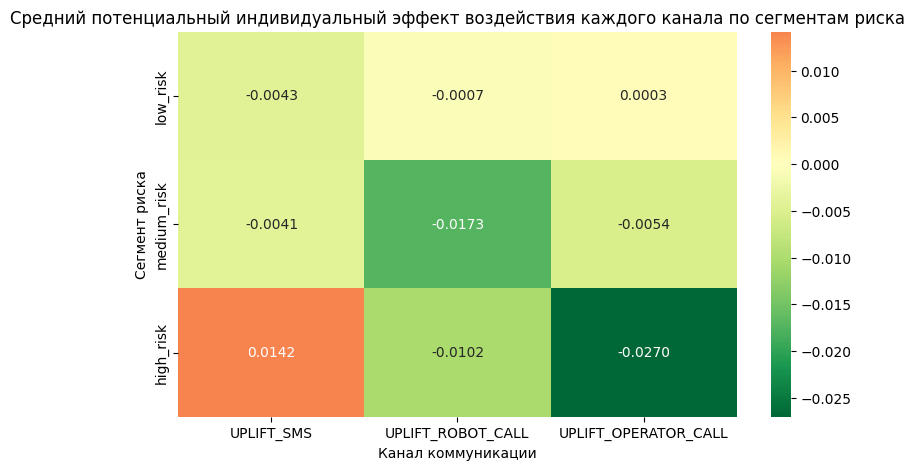

,UPLIFT_SMS,UPLIFT_ROBOT_CALL,UPLIFT_OPERATOR_CALL
RISK_SEGMENT,,,
low_risk,-0.00431,-0.00073,0.00033
medium_risk,-0.00408,-0.01727,-0.00540
high_risk,0.01415,-0.01021,-0.02703


In [32]:
potential_uplift_by_segment = df.groupby("RISK_SEGMENT")[[
    "UPLIFT_SMS", "UPLIFT_ROBOT_CALL", "UPLIFT_OPERATOR_CALL",
]].mean().reindex(["low_risk", "medium_risk", "high_risk"])

plt.figure(figsize=(9, 5))
sns.heatmap(potential_uplift_by_segment, annot=True, cmap="RdYlGn_r", center=0, fmt=".4f")
plt.title("Средний потенциальный индивидуальный эффект воздействия каждого канала по сегментам риска")
plt.xlabel("Канал коммуникации")
plt.ylabel("Сегмент риска")
plt.show()

potential_uplift_by_segment.round(5)


**Что показывает heatmap.** Здесь анализируются все потенциальные каналы для всех клиентов, включая те, которые фактически не были назначены. Это более строгая проверка гетерогенности: она показывает, что оптимальный канал зависит от профиля клиента, а задача не сводится к простому правилу “контактировать всех одним способом”.


In [33]:
sleeping_dog_summary = []
for channel, uplift_col in channel_uplift_cols.items():
    sleeping_dog_summary.append({
        "channel": channel,
        "mean_uplift": df[uplift_col].mean(),
        "share_beneficial_uplift_%": (df[uplift_col] < 0).mean() * 100,
        "share_negative_response_%": (df[uplift_col] > 0).mean() * 100,
        "p10": df[uplift_col].quantile(0.10),
        "p50": df[uplift_col].quantile(0.50),
        "p90": df[uplift_col].quantile(0.90),
    })

pd.DataFrame(sleeping_dog_summary).round(4)


,channel,mean_uplift,share_beneficial_uplift_%,share_negative_response_%,p10,p50,p90
0,sms,0.0019,53.2586,46.7414,-0.0100,-0.0007,0.0170
1,robot_call,-0.0094,81.0937,18.9063,-0.0244,-0.0073,0.0027
2,operator_call,-0.0107,76.0435,23.9565,-0.0305,-0.0058,0.0038


**Почему это важно.** `share_negative_response_%` показывает долю клиентов, для которых конкретный канал может быть вреден. В индивидуальный эффект воздействия-терминологии это близко к sleeping dogs: если их не трогать, риск ниже, а коммуникация способна ухудшить исход. Для кредитного CRM это особенно важно, потому что классическая risk-модель может выбрать клиента только из-за высокого риска дефолта, не проверяя, поможет ли контакт именно этому клиенту.


### Выводы по потенциальным исходам

Поля `PD_*` и `UPLIFT_*` согласованы между собой и показывают неоднородность каналов. У части клиентов некоторые воздействия полезны, у части - почти нейтральны, у части могут быть вредны.

Эта проверка поддерживает практическую идею работы: в финтехе важно выбирать не только клиента для коммуникации, но и канал, стоимость и интенсивность воздействия.

### 2.7 Oracle policy: две верхние границы качества

Oracle-поля используются только для оценки. Важно различать два ориентира: logged-policy oracle ранжирует клиентов внутри фактически назначенной политики, а counterfactual channel oracle знает лучший канал для каждого клиента.

Их нельзя смешивать: первый оценивает качество ранжирования в исторических данных, второй показывает нереализованный потенциал изменения самой политики.

In [34]:
policy_summary = pd.DataFrame({
    "policy": ["current_bank_policy", "oracle_policy", "no_contact_all"],
    "mean_pd_after": [
        df["PD_AFTER_CONTACT"].mean(),
        df["ORACLE_PD_AFTER_CONTACT"].mean(),
        df["PD_NO_CONTACT"].mean(),
    ],
})
policy_summary["delta_vs_no_contact_pp"] = (policy_summary["mean_pd_after"] - df["PD_NO_CONTACT"].mean()) * 100
policy_summary["delta_vs_current_pp"] = (policy_summary["mean_pd_after"] - df["PD_AFTER_CONTACT"].mean()) * 100
policy_summary.round(4)


,policy,mean_pd_after,delta_vs_no_contact_pp,delta_vs_current_pp
0,current_bank_policy,0.0775,-0.2488,0.0000
1,oracle_policy,0.0631,-1.6947,-1.4459
2,no_contact_all,0.0800,0.0000,0.2488


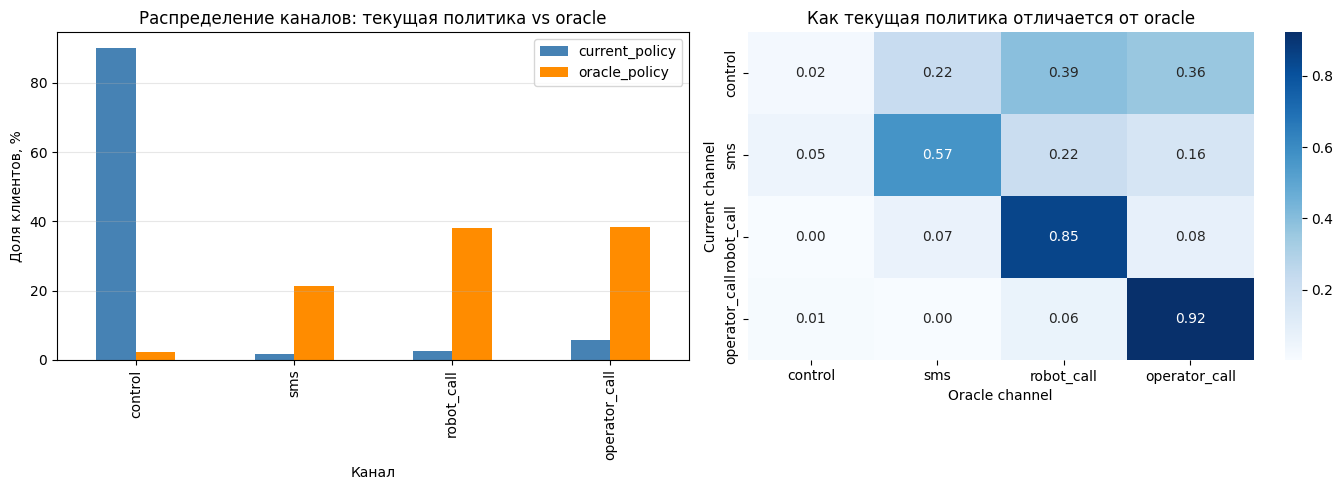

ORACLE_COMMUNICATION,control,sms,robot_call,operator_call
COMMUNICATION,,,,
control,0.022,0.225,0.392,0.361
sms,0.054,0.570,0.218,0.158
robot_call,0.004,0.066,0.848,0.082
operator_call,0.013,0.004,0.062,0.922


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

channel_order = ["control", "sms", "robot_call", "operator_call"]
oracle_dist = (df["ORACLE_COMMUNICATION"].value_counts(normalize=True) * 100).reindex(channel_order)
current_dist = (df["COMMUNICATION"].value_counts(normalize=True) * 100).reindex(channel_order)

pd.DataFrame({"current_policy": current_dist, "oracle_policy": oracle_dist}).plot(
    kind="bar", ax=axes[0], color=["steelblue", "darkorange"]
)
axes[0].set_title("Распределение каналов: текущая политика vs oracle")
axes[0].set_ylabel("Доля клиентов, %")
axes[0].set_xlabel("Канал")
axes[0].grid(True, alpha=0.3, axis="y")

policy_crosstab = pd.crosstab(df["COMMUNICATION"], df["ORACLE_COMMUNICATION"], normalize="index").reindex(
    index=channel_order, columns=channel_order
)
sns.heatmap(policy_crosstab, annot=True, fmt=".2f", cmap="Blues", ax=axes[1])
axes[1].set_title("Как текущая политика отличается от oracle")
axes[1].set_xlabel("Oracle channel")
axes[1].set_ylabel("Current channel")

plt.tight_layout()
plt.show()

policy_crosstab.round(3)


**Вывод по oracle policy.** Если средняя вероятность дефолта у oracle policy заметно ниже, чем у текущей синтетической политики банка, значит в данных действительно есть пространство для оптимизации каналов. Это пространство и является зоной, где индивидуальный эффект воздействия-модели могут дать практический выигрыш: не просто предсказать высокий риск, а выбрать воздействие, которое именно для данного клиента снижает риск сильнее всего.


### Выводы по oracle policy

Разрыв между текущей политикой и counterfactual oracle показывает, что значительная часть потенциального эффекта не реализуется. Это не означает, что нужно контактировать всех клиентов; oracle не учитывает стоимость, емкость и клиентский опыт.

Вывод для работы: качество модели и ценность политики нужно обсуждать отдельно. Хорошая модель ранжирования полезна только тогда, когда банк может безопасно менять правила коммуникаций.

### 2.8 Аудит утечки данных

В этом блоке проверяется, какие переменные нельзя использовать как обычные признаки. В причинной задаче leakage особенно опасен: post-treatment и oracle-поля могут дать красивую метрику, но полностью разрушить прикладной смысл модели.

In [36]:
if feature_roles:
    leakage_cols = feature_roles["leakage_cols_for_modeling"]
else:
    leakage_cols = [
        "BASE_PD", "CONTACT_PROPENSITY", "COMMUNICATION", "RISK_SEGMENT",
        "CONTACT_HISTORY", "PREFERRED_CHANNEL", "INTERACTION_SCORE", "DELAY_FLAG",
        "PD_NO_CONTACT", "PD_SMS", "PD_ROBOT_CALL", "PD_OPERATOR_CALL",
        "UPLIFT_SMS", "UPLIFT_ROBOT_CALL", "UPLIFT_OPERATOR_CALL",
        "TRUE_UPLIFT", "PD_AFTER_CONTACT", "TARGET_AFTER_CONTACT",
        "ORACLE_COMMUNICATION", "ORACLE_TRUE_UPLIFT", "ORACLE_PD_AFTER_CONTACT", "TARGET",
    ]

leakage_present = [col for col in leakage_cols if col in df.columns]
safe_candidate_cols = [
    col for col in df.columns
    if col not in leakage_present and col != "SK_ID_CURR" and not col.endswith("_BIN") and col != "TREATED"
]

leakage_audit = pd.DataFrame({
    "group": ["leakage_cols_present", "safe_candidate_features", "total_columns"],
    "count": [len(leakage_present), len(safe_candidate_cols), df.shape[1]],
})

display(leakage_audit)
print(leakage_present)


,group,count
0,leakage_cols_present,22
1,safe_candidate_features,150
2,total_columns,176


['BASE_PD', 'COMMUNICATION', 'CONTACT_HISTORY', 'CONTACT_PROPENSITY', 'DELAY_FLAG', 'INTERACTION_SCORE', 'ORACLE_COMMUNICATION', 'ORACLE_PD_AFTER_CONTACT', 'ORACLE_TRUE_UPLIFT', 'PD_AFTER_CONTACT', 'PD_NO_CONTACT', 'PD_OPERATOR_CALL', 'PD_ROBOT_CALL', 'PD_SMS', 'PREFERRED_CHANNEL', 'RISK_SEGMENT', 'TARGET', 'TARGET_AFTER_CONTACT', 'TRUE_UPLIFT', 'UPLIFT_OPERATOR_CALL', 'UPLIFT_ROBOT_CALL', 'UPLIFT_SMS']


### Выводы по аудиту утечки

Список запрещенных признаков отделяет исходные клиентские признаки от treatment, outcome, потенциальных исходов и oracle-полей. Это обеспечивает честное сравнение риск-моделей и uplift-моделей.

В практическом внедрении такой leakage audit должен быть обязательным этапом перед обучением.

## 3. Финальные выводы о качестве синтетического набора данных

Аудит отвечает на главный вопрос этой части работы: можно ли использовать набор данных как стенд для проверки uplift-моделирования в финтехе.

In [37]:
# Сводная таблица ключевых характеристик набора данных
summary = {
    'Всего наблюдений':          len(df),
    'Treated (contacted), %':    round(df['TREATED'].mean() * 100, 1),
    'Control (no contact), %':   round((1 - df['TREATED'].mean()) * 100, 1),
    'Default rate (TARGET), %':  round(df['TARGET'].mean() * 100, 2),
    'Default rate (T_A_C), %':   round(df['TARGET_AFTER_CONTACT'].mean() * 100, 2),
    'ROC-AUC (BASE_PD → TARGET)': round(roc_auc_score(df['TARGET'], df['BASE_PD']), 3),
    'Avg TRUE_UPLIFT (treated)':  round(df[df['TREATED']==1]['TRUE_UPLIFT'].mean(), 5),
    'Std TRUE_UPLIFT (treated)':  round(df[df['TREATED']==1]['TRUE_UPLIFT'].std(), 5),
    'Segments':                   df['RISK_SEGMENT'].nunique(),
    'Channels (excl. control)':   df['COMMUNICATION'].nunique() - 1,
}
import pandas as pd
pd.DataFrame(summary.items(), columns=['Характеристика', 'Значение'])

,Характеристика,Значение
0,Всего наблюдений,307511.00000
1,"Treated (contacted), %",9.90000
2,"Control (no contact), %",90.10000
3,"Default rate (TARGET), %",8.07000
4,"Default rate (T_A_C), %",7.73000
5,ROC-AUC (BASE_PD → TARGET),0.69500
6,Avg TRUE_UPLIFT (treated),-0.02522
7,Std TRUE_UPLIFT (treated),0.02673
8,Segments,3.00000
9,Channels (excl. control),3.00000


**Ключевые итоги аудита:**

- `BASE_PD` сохраняет связь с кредитным риском и отделяет более рискованных заемщиков.
- `CONTACT_PROPENSITY` и `COMMUNICATION` создают реалистичное смещение назначения контактов.
- `TRUE_UPLIFT` слабый, неоднородный и зависит от канала, сегмента и истории контактов.
- Потенциальные исходы позволяют проверять multi-treatment постановку и oracle-ориентиры.
- Leakage audit фиксирует границу между признаками модели и полями, доступными только для оценки.

Следующий шаг - использовать этот стенд для сравнения сильных риск-моделей и моделей индивидуального эффекта.